In [15]:
import pandas as pd
df = pd.read_csv('./atomic_lines.csv')
df.to_csv('./atomic_lines.csv',index=None,sep='\t')

In [2]:

df.columns

Index(['element', 'wave_A', 'wave_nm', 'loggf', 'lower_state_eV',
       'lower_state_cm1', 'lower_j', 'upper_state_eV', 'upper_state_cm1',
       'upper_j', 'upper_g', 'lande_lower', 'lande_upper',
       'spectrum_transition_type', 'turbospectrum_rad', 'rad', 'stark',
       'waals', 'waals_single_gamma_format', 'turbospectrum_fdamp',
       'spectrum_fudge_factor', 'theoretical_depth', 'theoretical_ew',
       'lower_orbital_type', 'upper_orbital_type', 'molecule',
       'spectrum_synthe_isotope', 'ion', 'spectrum_moog_species',
       'turbospectrum_species', 'width_species', 'reference_code',
       'spectrum_support', 'turbospectrum_support', 'moog_support',
       'width_support', 'synthe_support', 'sme_support'],
      dtype='object')

In [5]:
df[['element', 'wave_A','loggf', 'lower_state_eV','lower_j', 'upper_state_eV', 'upper_j', 'upper_g','stark','theoretical_depth','theoretical_ew','upper_orbital_type', 'molecule','ion','reference_code']].to_csv('./tmp.csv',index=None)

In [10]:
import numpy as np
np.unique(df['ion'])

array([1, 2, 3, 4, 5, 6])

In [12]:
df['theoretical_depth']

0         0.03
1         0.00
2         0.00
3         0.00
4         0.00
          ... 
731372    0.00
731373    0.00
731374    0.00
731375    0.00
731376    0.00
Name: theoretical_depth, Length: 731377, dtype: float64

In [9]:
from binary_tools.gfp import GFP

In [ ]:
import binary_tools

2025-01-11 15:00:11.924847: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-11 15:00:11.979197: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-01-11 15:00:12.253802: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-11 15:00:12.253837: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-11 15:00:12.255189: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to regi

[LogicalDevice(name='/device:CPU:0', device_type='CPU')]


2025-01-11 15:00:16.177321: E tensorflow/compiler/xla/stream_executor/cuda/cuda_driver.cc:268] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


# Generate Spectrum

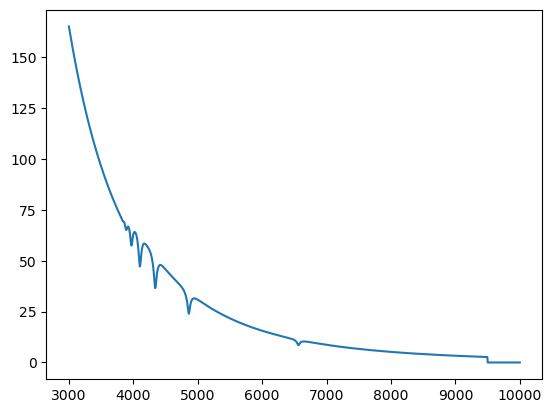

In [ ]:
from binary_tools.gfp import GFP,logteff_logg_to_mass
import numpy as np
from matplotlib import pyplot as plt
import astropy.units as u
import astropy.constants as c
wl = np.linspace(3000,10000,1000) #Ang
resolution = (wl.max()-wl.min())/len(wl)
specclass='DA'
logteff_logg_to_mass_DA = logteff_logg_to_mass(specclass)
gfp = GFP(resolution = resolution, specclass = specclass)
gfp.parallax=(1e3/2.711*u.pc).to(u.cm).value

Teff =33079 #K
logg=8.27 
rv = 19 #km/s
mass = logteff_logg_to_mass_DA(np.log10(Teff),logg)
radius = np.sqrt(mass*u.M_sun*c.G / (10**(logg)*u.cm/u.s**2)).to(u.R_sun).value

fl = gfp.spectrum_sampler(wl,np.array([[Teff,logg,radius,rv]]),specclass=specclass)
plt.plot(wl,fl)
